# Análisis de Vulnerabilidades de Dependencias — Grype

Análisis de los hallazgos de **Grype** sobre las dependencias declaradas en cada repositorio.  
El objetivo es clasificar las vulnerabilidades por **severidad**, **tipo de paquete**, **ecosistema**, **CVE/GHSA** y disponibilidad de **fix**, para priorizar remediaciones.

**Archivos fuente:** `{repo}-grype.json` (normalizado) + `{repo}-grype-raw.json` (Grype nativo)  
**Campos clave:** `vuln_severity`, `vuln_id`, `package_name`, `fix_version`, `cwe`, `cvss_score`

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RESULTS_DIR  = Path('../../data/results')
GRYPE_FILES  = sorted(RESULTS_DIR.glob('*-grype.json'))
RAW_FILES    = {f.name.replace('-grype-raw.json', ''): f
                for f in RESULTS_DIR.glob('*-grype-raw.json')}

assert GRYPE_FILES, 'No se encontraron archivos Grype. Ejecuta el pipeline primero.'
print(f'Archivos Grype encontrados: {len(GRYPE_FILES)}')
for f in GRYPE_FILES:
    print(' -', f.name)

Archivos Grype encontrados: 9
 - Requests-grype.json
 - WordPress-Coding-Standards-grype.json
 - WordPress-grype.json
 - agent-skills-grype.json
 - gutenberg-examples-grype.json
 - gutenberg-grype.json
 - mcp-adapter-grype.json
 - two-factor-grype.json
 - wordpress-develop-grype.json


## 1. Carga del formato normalizado

In [2]:
SEVERIDAD_ORDEN = ['critical', 'high', 'medium', 'low', 'negligible', 'unknown']

registros = []
for gf in GRYPE_FILES:
    repo = gf.name.replace('-grype.json', '')
    data = json.loads(gf.read_text(encoding='utf-8'))

    for v in data.get('vulnerabilities', []):
        vuln_id = v.get('vuln_id', '')
        es_ghsa = vuln_id.upper().startswith('GHSA')
        es_cve  = vuln_id.upper().startswith('CVE')
        tiene_fix = str(v.get('fix_version', 'N/A')).strip().upper() not in ('N/A', '', 'NONE', 'UNKNOWN')

        registros.append({
            'repositorio':  repo,
            'paquete':      v.get('package_name', ''),
            'version':      v.get('current_version', ''),
            'vuln_id':      vuln_id,
            'tipo_id':      'GHSA' if es_ghsa else 'CVE' if es_cve else 'otro',
            'severidad':    v.get('vuln_severity', 'unknown').lower(),
            'fix_version':  v.get('fix_version', 'N/A'),
            'tiene_fix':    tiene_fix,
            'mensaje':      v.get('message', ''),
            'cwe':          v.get('cwe', 'N/A'),
            'cvss_score':   float(v.get('cvss_score', 0) or 0),
        })

# Enriquecer con tipo de paquete / lenguaje desde el raw
raw_lookup: dict[tuple, dict] = {}
for repo_name, raw_file in RAW_FILES.items():
    raw = json.loads(raw_file.read_text(encoding='utf-8'))
    for m in raw.get('matches', []):
        art = m.get('artifact', {})
        key = (repo_name, art.get('name',''), art.get('version',''))
        raw_lookup[key] = {
            'tipo_paquete': art.get('type', ''),
            'lenguaje':     art.get('language', ''),
            'namespace':    m.get('vulnerability', {}).get('namespace', ''),
            'match_type':   m.get('matchDetails', [{}])[0].get('type', '') if m.get('matchDetails') else '',
        }

for r in registros:
    extra = raw_lookup.get((r['repositorio'], r['paquete'], r['version']), {})
    r['tipo_paquete'] = extra.get('tipo_paquete', 'desconocido')
    r['lenguaje']     = extra.get('lenguaje', 'desconocido')
    r['namespace']    = extra.get('namespace', '')
    r['match_type']   = extra.get('match_type', '')

df = pd.DataFrame(registros)
print(f'Total de vulnerabilidades: {len(df)}')
print(f'Repositorios con datos: {df["repositorio"].nunique() if not df.empty else 0}')
df.head()

Total de vulnerabilidades: 173
Repositorios con datos: 4


,repositorio,paquete,version,vuln_id,tipo_id,severidad,fix_version,tiene_fix,mensaje,cwe,cvss_score,tipo_paquete,lenguaje,namespace,match_type
0,WordPress,twentytwentyone,2.8.0,GHSA-q87j-q95m-j3x3,GHSA,critical,N/A,False,Malware in twentytwentyone,N/A,0.0,npm,javascript,github:language:javascript,exact-direct-match
1,gutenberg,ip,1.1.9,GHSA-2p57-rm9w-gvfp,GHSA,high,N/A,False,ip SSRF improper categorization in isPublic,N/A,8.1,npm,javascript,github:language:javascript,exact-direct-match
2,gutenberg,trim,0.0.1,GHSA-w5p7-h5w8-2hfq,GHSA,high,0.0.3,True,Regular Expression Denial of Service in trim,N/A,7.5,npm,javascript,github:language:javascript,exact-direct-match
3,gutenberg,lodash.set,4.3.2,GHSA-p6mc-m468-83gw,GHSA,high,N/A,False,Prototype Pollution in lodash,N/A,7.4,npm,javascript,github:language:javascript,exact-direct-match
4,gutenberg,body-parser,1.20.1,GHSA-qwcr-r2fm-qrc7,GHSA,high,1.20.3,True,body-parser vulnerable to denial of service wh...,N/A,7.5,npm,javascript,github:language:javascript,exact-direct-match


## 2. Vulnerabilidades por repositorio y severidad

severidad,critical,high,medium,low
repositorio,,,,
WordPress,1,0,0,0
gutenberg,2,73,73,16
two-factor,0,0,4,0
wordpress-develop,2,1,1,0


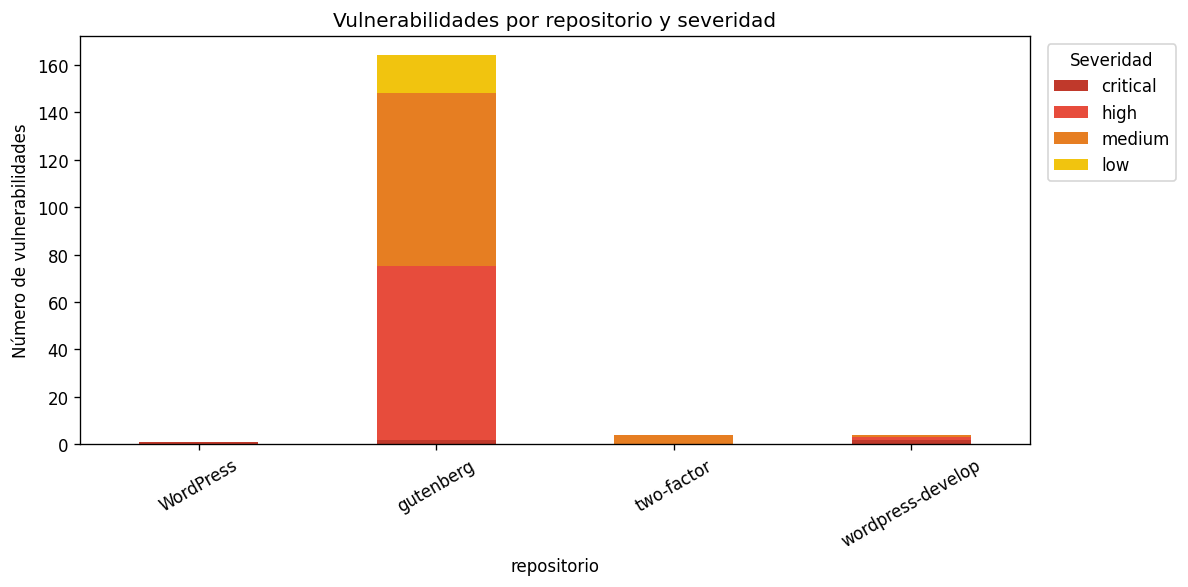

In [3]:
if df.empty:
    print('Sin hallazgos.')
else:
    pivot_sev = df.pivot_table(
        index='repositorio', columns='severidad',
        values='vuln_id', aggfunc='count', fill_value=0
    )
    sev_cols = [c for c in SEVERIDAD_ORDEN if c in pivot_sev.columns]
    colores_sev = {
        'critical': '#c0392b', 'high': '#e74c3c', 'medium': '#e67e22',
        'low': '#f1c40f', 'negligible': '#95a5a6', 'unknown': '#bdc3c7'
    }
    display(pivot_sev[sev_cols])

    pivot_sev[sev_cols].plot(
        kind='bar', stacked=True, figsize=(10, 5),
        color=[colores_sev.get(c, 'gray') for c in sev_cols]
    )
    plt.title('Vulnerabilidades por repositorio y severidad')
    plt.ylabel('Número de vulnerabilidades')
    plt.legend(title='Severidad', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

## 3. Distribución global de severidad

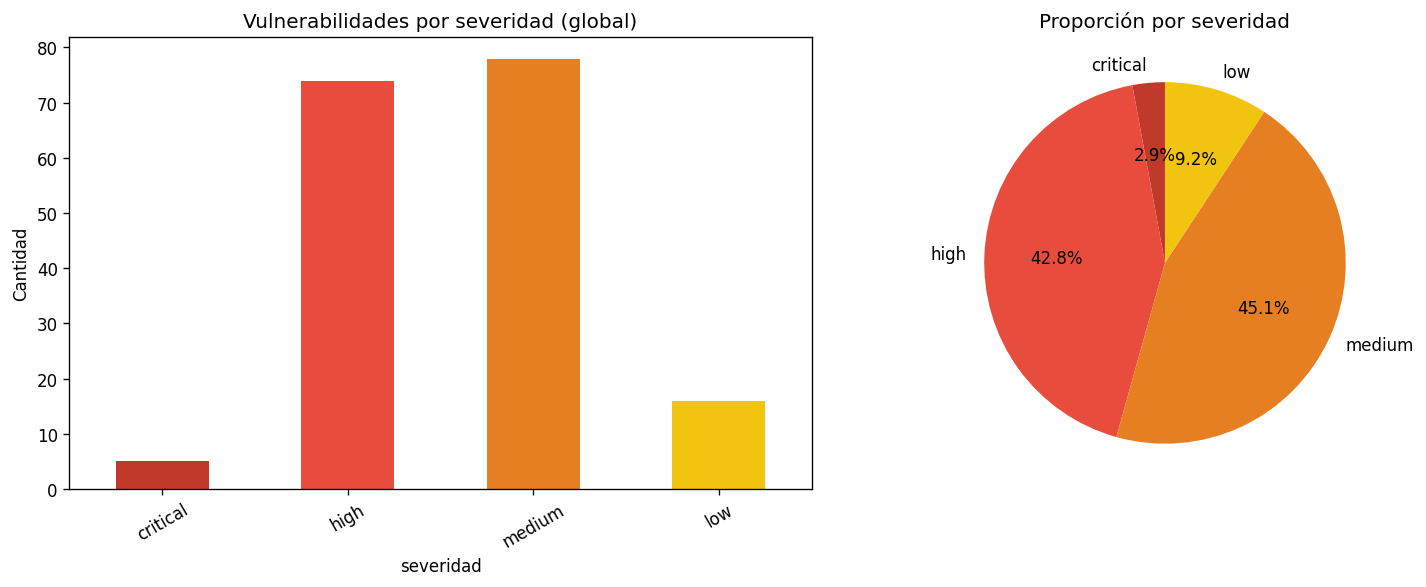

In [4]:
if not df.empty:
    sev_global = df['severidad'].value_counts()
    sev_ord = sev_global.reindex([s for s in SEVERIDAD_ORDEN if s in sev_global.index])
    colores = [colores_sev.get(s, 'gray') for s in sev_ord.index]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sev_ord.plot(kind='bar', ax=axes[0], color=colores)
    axes[0].set_title('Vulnerabilidades por severidad (global)')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].pie(sev_ord, labels=sev_ord.index, autopct='%1.1f%%', colors=colores, startangle=90)
    axes[1].set_title('Proporción por severidad')
    plt.tight_layout()
    plt.show()

## 4. Tipo de identificador de vulnerabilidad (CVE vs GHSA)

Distribución por tipo de identificador:
tipo_id
GHSA    173


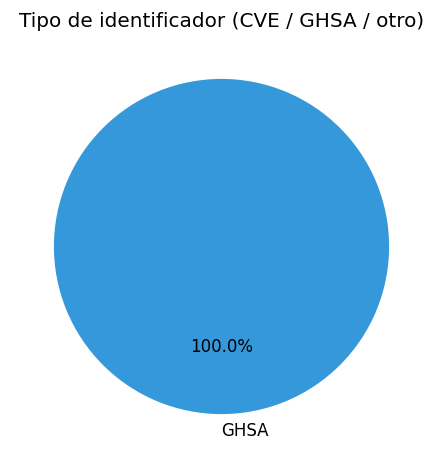

In [5]:
if not df.empty:
    tipo_id_counts = df['tipo_id'].value_counts()
    print('Distribución por tipo de identificador:')
    print(tipo_id_counts.to_string())

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.pie(tipo_id_counts, labels=tipo_id_counts.index,
           autopct='%1.1f%%', colors=['#3498db', '#e74c3c', '#95a5a6'],
           startangle=90)
    ax.set_title('Tipo de identificador (CVE / GHSA / otro)')
    plt.tight_layout()
    plt.show()

## 5. Ecosistemas y tipos de paquete afectados

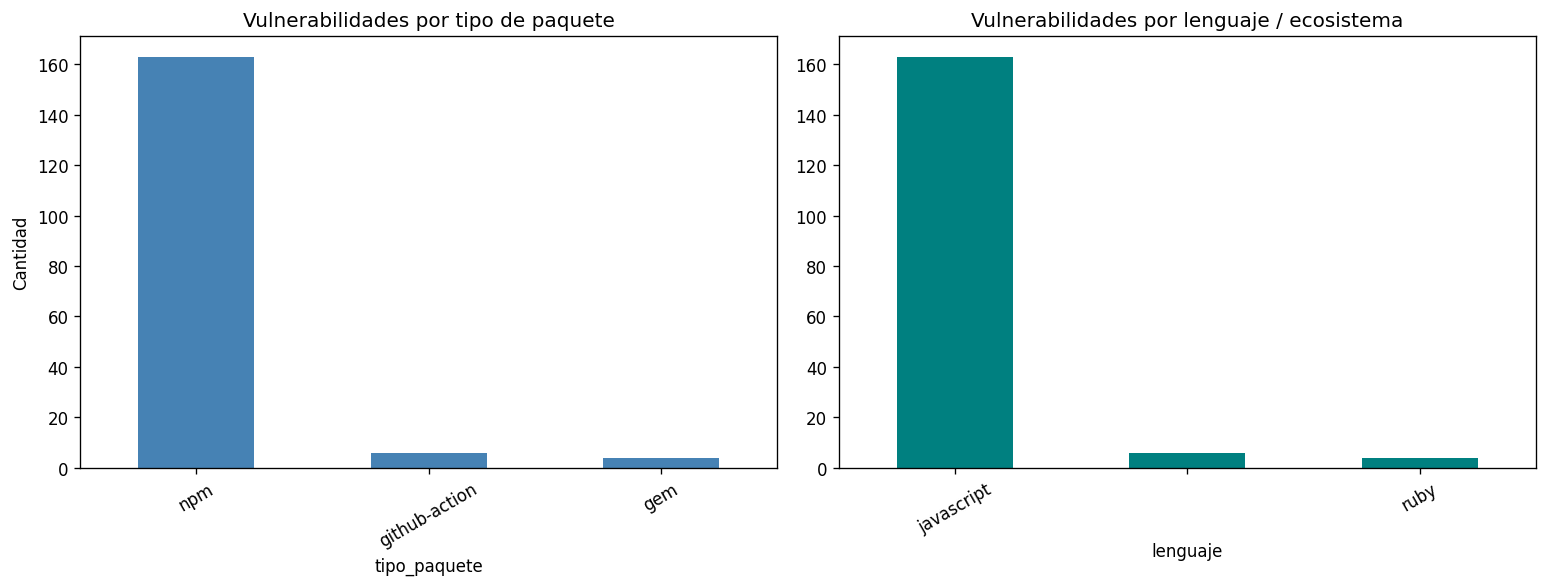

In [6]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    tipo_pkg = df['tipo_paquete'].value_counts()
    tipo_pkg.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Vulnerabilidades por tipo de paquete')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=30)

    lang_counts = df['lenguaje'].value_counts()
    lang_counts.plot(kind='bar', ax=axes[1], color='teal')
    axes[1].set_title('Vulnerabilidades por lenguaje / ecosistema')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

## 6. Disponibilidad de fix por severidad

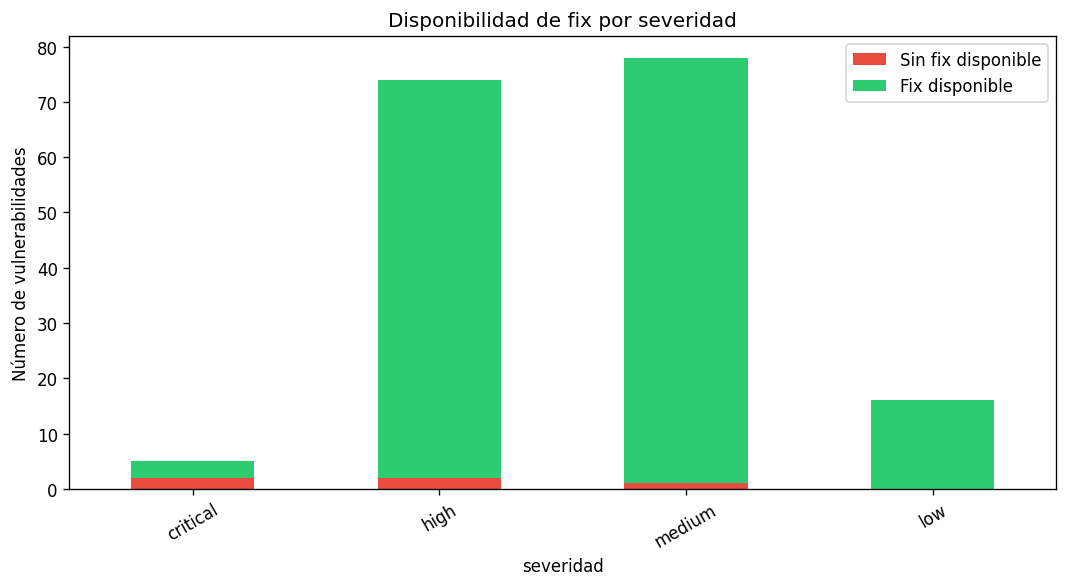

Porcentaje con fix disponible: 97.1%


In [7]:
if not df.empty:
    fix_sev = df.groupby(['severidad', 'tiene_fix']).size().unstack(fill_value=0)
    fix_sev = fix_sev.reindex([s for s in SEVERIDAD_ORDEN if s in fix_sev.index])
    fix_sev.columns = ['Sin fix disponible', 'Fix disponible']

    fix_sev.plot(kind='bar', stacked=True, figsize=(9, 5),
                 color=['#e74c3c', '#2ecc71'])
    plt.title('Disponibilidad de fix por severidad')
    plt.ylabel('Número de vulnerabilidades')
    plt.legend()
    plt.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

    pct_fix = (df['tiene_fix'].sum() / len(df) * 100)
    print(f'Porcentaje con fix disponible: {pct_fix:.1f}%')

## 7. Distribución de CVSS Score

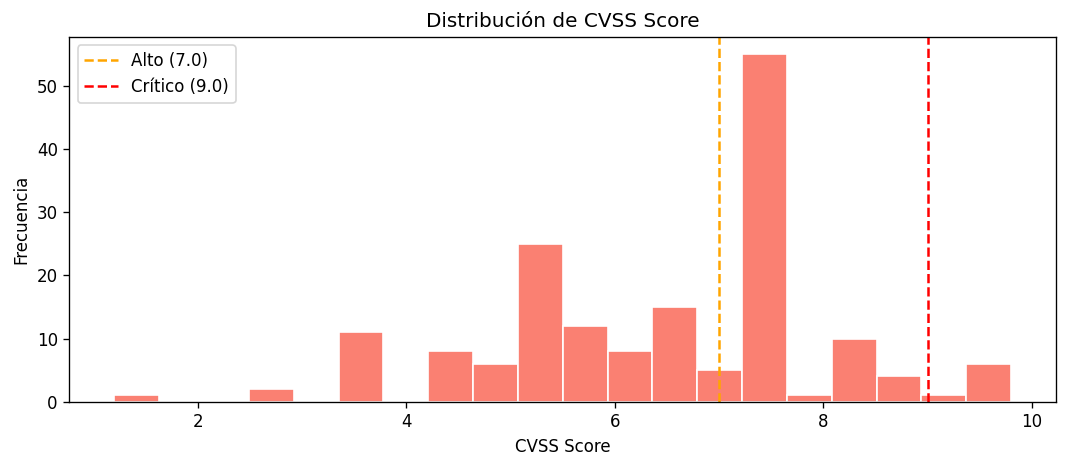

count    170.00
mean       6.47
std        1.56
min        1.20
25%        5.30
50%        6.50
75%        7.50
max        9.80
Name: cvss_score, dtype: float64


In [8]:
if not df.empty:
    scores = df[df['cvss_score'] > 0]['cvss_score']
    if scores.empty:
        print('No hay scores CVSS disponibles.')
    else:
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.hist(scores, bins=20, color='salmon', edgecolor='white')
        ax.axvline(7.0, color='orange', linestyle='--', label='Alto (7.0)')
        ax.axvline(9.0, color='red', linestyle='--', label='Crítico (9.0)')
        ax.set_title('Distribución de CVSS Score')
        ax.set_xlabel('CVSS Score')
        ax.set_ylabel('Frecuencia')
        ax.legend()
        plt.tight_layout()
        plt.show()
        print(scores.describe().round(2))

## 8. Top vulnerabilidades más frecuentes entre repositorios

In [9]:
if not df.empty:
    top_vulns = (df.groupby(['vuln_id', 'severidad', 'mensaje'])
                   .agg(repositorios=('repositorio', 'nunique'),
                        paquetes=('paquete', 'nunique'))
                   .reset_index()
                   .sort_values(['repositorios', 'paquetes'], ascending=False)
                   .head(20))
    display(top_vulns.reset_index(drop=True))

,vuln_id,severidad,mensaje,repositorios,paquetes
0,GHSA-5wxr-w449-57cm,medium,Setup PHP: GitHub tokens configured by setup-p...,2,1
1,GHSA-f886-m6hf-6m8v,medium,brace-expansion: Zero-step sequence causes pro...,2,1
2,GHSA-pqwm-q9pv-ph8r,medium,Setup PHP: Command Injection in Repository-Der...,2,1
3,GHSA-q87j-q95m-j3x3,critical,Malware in twentytwentyone,2,1
4,GHSA-f23m-r3pf-42rh,medium,lodash vulnerable to Prototype Pollution via a...,1,2
5,GHSA-r5fr-rjxr-66jc,high,lodash vulnerable to Code Injection via `_.tem...,1,2
6,GHSA-xxjr-mmjv-4gpg,medium,Lodash has Prototype Pollution Vulnerability i...,1,2
7,GHSA-2328-f5f3-gj25,high,Forge has a basicConstraints bypass in its cer...,1,1
8,GHSA-23c5-xmqv-rm74,high,minimatch ReDoS: nested *() extglobs generate ...,1,1
9,GHSA-2g4f-4pwh-qvx6,medium,ajv has ReDoS when using `$data` option,1,1


## 9. Paquetes con más vulnerabilidades críticas o altas

In [10]:
if not df.empty:
    criticos_altos = df[df['severidad'].isin(['critical', 'high'])]
    if criticos_altos.empty:
        print('No hay vulnerabilidades críticas o altas.')
    else:
        top_pkg = (
            criticos_altos.groupby(['repositorio', 'paquete', 'version'])
            .agg(criticas=('severidad', lambda x: (x == 'critical').sum()),
                 altas=('severidad', lambda x: (x == 'high').sum()))
            .reset_index()
            .assign(total=lambda d: d['criticas'] + d['altas'])
            .sort_values('total', ascending=False)
            .head(20)
        )
        top_pkg['etiqueta'] = top_pkg['repositorio'] + '/' + top_pkg['paquete'] + '@' + top_pkg['version']
        top_pkg.set_index('etiqueta')[['criticas', 'altas']].sort_values('total').plot(
            kind='barh', stacked=True, figsize=(10, 7),
            color=['#c0392b', '#e74c3c']
        )
        plt.title('Top 20 paquetes con más vulns. críticas + altas')
        plt.xlabel('Número de vulnerabilidades')
        plt.tight_layout()
        plt.show()

KeyError: 'total'